<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_060_smote.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 60/365 — SMOTE
## Can we help a model learn the minority class by creating synthetic examples?

Yesterday we explored **Class Imbalance**.

Today we cover one of the most popular techniques for imbalanced datasets:

**SMOTE — Synthetic Minority Over-sampling Technique**

Instead of simply copying minority examples, SMOTE creates new synthetic minority points between existing minority observations.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    raise ImportError("Install once with: pip install imbalanced-learn")


## 1. Create a 95:5 imbalanced dataset


In [2]:
X,y=make_classification(
    n_samples=4000,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    weights=[0.95,0.05],
    class_sep=1.2,
    random_state=42
)

print(pd.Series(y).value_counts())


0    3787
1     213
Name: count, dtype: int64


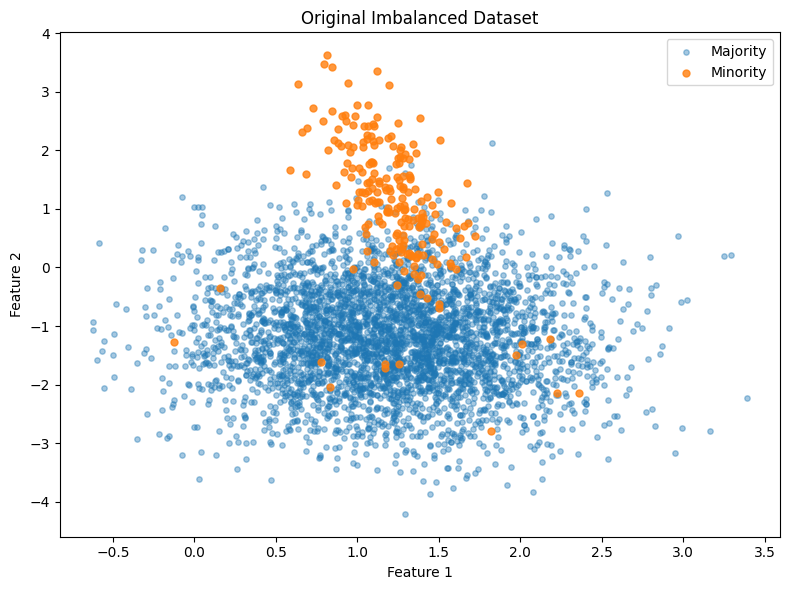

In [3]:
plt.figure(figsize=(8,6))
plt.scatter(X[y==0,0],X[y==0,1],s=15,alpha=0.4,label="Majority")
plt.scatter(X[y==1,0],X[y==1,1],s=25,alpha=0.8,label="Minority")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Imbalanced Dataset")
plt.legend()
plt.tight_layout()
plt.show()


## 2. Split before applying SMOTE

SMOTE must be applied **only to the training data**.

Otherwise synthetic information can leak into evaluation.


In [4]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,random_state=42,stratify=y
)

print("Train distribution:")
print(pd.Series(y_train).value_counts())
print("\nTest distribution:")
print(pd.Series(y_test).value_counts())


Train distribution:
0    2840
1     160
Name: count, dtype: int64

Test distribution:
0    947
1     53
Name: count, dtype: int64


## 3. Baseline Logistic Regression


In [5]:
baseline=LogisticRegression(max_iter=2000)
baseline.fit(X_train,y_train)

baseline_pred=baseline.predict(X_test)

print(classification_report(
    y_test,
    baseline_pred,
    digits=3,
    zero_division=0
))


              precision    recall  f1-score   support

           0      0.969     0.994     0.981       947
           1      0.793     0.434     0.561        53

    accuracy                          0.964      1000
   macro avg      0.881     0.714     0.771      1000
weighted avg      0.960     0.964     0.959      1000



## 4. Apply SMOTE only to the training set


In [6]:
smote=SMOTE(random_state=42,k_neighbors=5)

X_train_smote,y_train_smote=smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(pd.Series(y_train).value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())


Before SMOTE:
0    2840
1     160
Name: count, dtype: int64

After SMOTE:
1    2840
0    2840
Name: count, dtype: int64


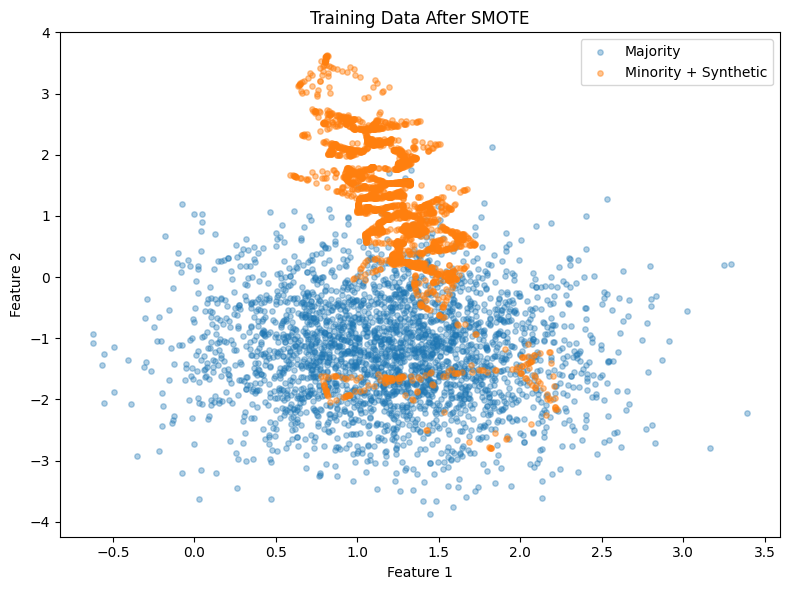

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_train_smote[y_train_smote==0,0],
    X_train_smote[y_train_smote==0,1],
    s=15,alpha=0.35,label="Majority"
)
plt.scatter(
    X_train_smote[y_train_smote==1,0],
    X_train_smote[y_train_smote==1,1],
    s=15,alpha=0.45,label="Minority + Synthetic"
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training Data After SMOTE")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Train on the SMOTE-resampled data


In [8]:
smote_model=LogisticRegression(max_iter=2000)
smote_model.fit(X_train_smote,y_train_smote)

smote_pred=smote_model.predict(X_test)

print(classification_report(
    y_test,
    smote_pred,
    digits=3,
    zero_division=0
))


              precision    recall  f1-score   support

           0      0.990     0.907     0.947       947
           1      0.333     0.830     0.476        53

    accuracy                          0.903      1000
   macro avg      0.661     0.869     0.711      1000
weighted avg      0.955     0.903     0.922      1000



## 6. Compare Baseline vs SMOTE


In [9]:
comparison=pd.DataFrame({
    "Model":["Baseline","SMOTE"],
    "Accuracy":[
        accuracy_score(y_test,baseline_pred),
        accuracy_score(y_test,smote_pred)
    ],
    "Precision":[
        precision_score(y_test,baseline_pred,zero_division=0),
        precision_score(y_test,smote_pred,zero_division=0)
    ],
    "Recall":[
        recall_score(y_test,baseline_pred,zero_division=0),
        recall_score(y_test,smote_pred,zero_division=0)
    ],
    "F1":[
        f1_score(y_test,baseline_pred,zero_division=0),
        f1_score(y_test,smote_pred,zero_division=0)
    ]
})

display(comparison.round(3))


,Model,Accuracy,Precision,Recall,F1
0,Baseline,0.964,0.793,0.434,0.561
1,SMOTE,0.903,0.333,0.830,0.476


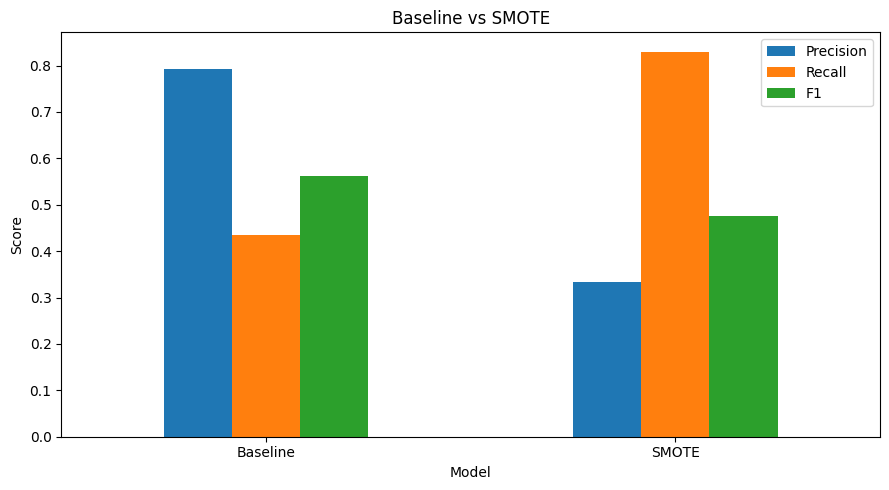

In [10]:
comparison.set_index("Model")[["Precision","Recall","F1"]].plot(
    kind="bar",
    figsize=(9,5)
)
plt.ylabel("Score")
plt.title("Baseline vs SMOTE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## How SMOTE works — intuition

If two minority examples are:

`A = (2,3)`

`B = (4,5)`

SMOTE may create a synthetic point somewhere between them, such as:

`(3,4)`

It does not simply duplicate an existing row.


## Enterprise intuition

SMOTE is commonly considered for rare-event problems such as:

- fraud detection
- customer churn
- equipment failure
- cybersecurity intrusion
- defect detection

It can improve minority-class recall, but may reduce precision.

That trade-off must be judged using business costs.


## Important limitations

SMOTE can create unrealistic synthetic points when:

- classes overlap heavily
- minority examples contain noise
- features are poorly scaled
- categorical features are handled naively

And SMOTE should **never** be applied to the final test set.

For cross-validation, use an `imblearn` pipeline so oversampling happens inside each training fold.


## What does this teach?

- SMOTE creates synthetic minority examples.
- It is different from simply duplicating minority rows.
- It can improve Recall on the rare class.
- Precision may decrease.
- Accuracy may fall while the model becomes more useful.
- Apply SMOTE only to training data.

> **The goal is not to make the dataset look balanced. The goal is to help the model learn the rare class without corrupting evaluation.**


## References

- https://arxiv.org/abs/1106.1813
- https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html
- https://imbalanced-learn.org/stable/user_guide.html
